Successfully loaded model from best_model_2807202510.pt
Successfully loaded dataset with 48600 samples
Using device: cuda
Processing power level 0 dBm with 2700 samples...
[0.61622 0.73379 0.8922  0.95858 1.071   1.16814 1.2243  1.30611 1.40315]
0       0.61622
1       0.61622
2       0.61622
3       0.61622
4       0.61622
         ...   
2695    1.40315
2696    1.40315
2697    1.40315
2698    1.40315
2699    1.40315
Name: Frequencies, Length: 2700, dtype: float64

Power 0 dBm Statistics:
  Frequencies tested: 9
  Maximum error: 53.812 MHz
  Mean error: 25.615 MHz
  Minimum error: 9.938 MHz
  Standard deviation: 13.997 MHz
Processing power level 10 dBm with 2700 samples...
[0.61622 0.73379 0.8922  0.95858 1.071   1.16814 1.2243  1.30611 1.40315]
0       0.61622
1       0.61622
2       0.61622
3       0.61622
4       0.61622
         ...   
2695    1.40315
2696    1.40315
2697    1.40315
2698    1.40315
2699    1.40315
Name: Frequencies, Length: 2700, dtype: float64

Power 10 dBm Stati

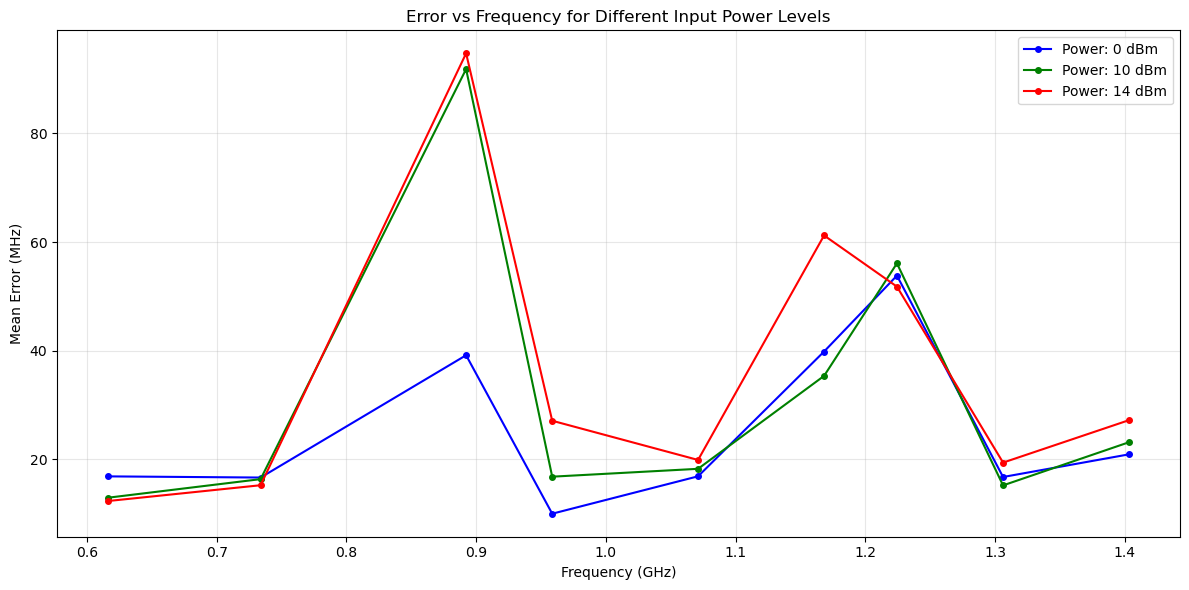


SUMMARY REPORT

Power Level: 0 dBm
  Mean Error: 25.615 ± 13.997 MHz
  Error Range: [9.938, 53.812] MHz
  Frequencies Tested: 9

Power Level: 10 dBm
  Mean Error: 31.743 ± 24.877 MHz
  Error Range: [12.887, 91.862] MHz
  Frequencies Tested: 9

Power Level: 14 dBm
  Mean Error: 36.518 ± 25.880 MHz
  Error Range: [12.275, 94.769] MHz
  Frequencies Tested: 9

Overall Performance:
  Best Mean Error: 25.615 MHz
  Worst Mean Error: 36.518 MHz
  Maximum Error Observed: 94.769 MHz


In [34]:
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import matplotlib.pyplot as plt
import torch as T
import pandas as pd
from scipy import signal
import math
from pathlib import Path

# ------------------- Helper Functions ----------------------

def get_data_in_array(dataframe, header_name, delim=True, size=400):
    """Extract and process array data from DataFrame column."""
    _results_array = np.zeros([len(dataframe), size])
    for i in range(len(dataframe)):
        _results = dataframe[header_name].iloc[i].strip()[1:-1]
        _results = _results.split(",") if delim else _results.split()
        np_array = [float(value.strip()) for value in _results]
        _results_array[i] = np.array(np_array)[:size]
    return _results_array

def get_datasets(dataset):
    """Create PyTorch dataset and dataloader from processed data."""
    x = get_data_in_array(dataframe=dataset, header_name='arcsin_results', delim=True).astype(float)
    y = get_data_in_array(dataframe=dataset, header_name='test_data', delim=True).astype(float)

    x = np.resize(x, (x.shape[0], 400))
    y = np.resize(y, (y.shape[0], 400))

    data_tensor = T.tensor(x, dtype=T.float32)
    targets_tensor = T.tensor(y, dtype=T.float32)

    testing_dataset = T.utils.data.TensorDataset(data_tensor, targets_tensor)
    testing_loader = T.utils.data.DataLoader(testing_dataset, batch_size=1, shuffle=False)
    freqs = dataset['Frequencies'].reset_index(drop=True)
    print(dataset['Frequencies'].unique())
    print(freqs)

    return testing_loader, freqs

def get_frequency_component(y):
    """Extract dominant frequency component from signal using periodogram."""
    y = y.view(-1).cpu().numpy()
    fs = 2e9  # Sampling frequency = 2 GHz
    N = 4 * 2**math.ceil(np.log2(len(y)))
    f, px = signal.periodogram(y, window='hann', nfft=N, fs=fs, scaling='spectrum')
    return f[np.argmax(px)] / 1e6  # return in MHz

def get_errors(loaded_model, device, testing_loader, freqs):
    """Calculate prediction errors for each frequency."""
    loaded_model.eval()
    loaded_model.to(device)

    freq_dict = {}
    meanlist = []
    prevfreq = None

    with T.no_grad():
        for i, (data, target) in enumerate(testing_loader):
            data = data.to(device)
            target = target.to(device)

            output = loaded_model(data)

            f_true = get_frequency_component(target)
            f_pred = get_frequency_component(output)

            current_freq = freqs[i]
            error = abs(f_true - f_pred)

            if current_freq != prevfreq:
                if prevfreq is not None:
                    freq_dict[prevfreq] = np.mean(meanlist)
                    meanlist = []
                prevfreq = current_freq

            meanlist.append(error)

        # Handle the last frequency group
        if prevfreq is not None:
            freq_dict[prevfreq] = np.mean(meanlist)

    return freq_dict

def load_model_safely(model_path):
    """Safely load PyTorch model with error handling."""
    try:
        if not Path(model_path).exists():
            raise FileNotFoundError(f"Model file not found: {model_path}")
        
        model = T.jit.load(model_path)
        print(f"Successfully loaded model from {model_path}")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        raise

def load_dataset_safely(csv_path):
    """Safely load CSV dataset with error handling."""
    try:
        if not Path(csv_path).exists():
            raise FileNotFoundError(f"CSV file not found: {csv_path}")
        
        dataset = pd.read_csv(
            csv_path,
            skiprows=[0],
            names=['Numbers', 'Frequencies', 'Powers', 'arcsin_results', 'test_data', 'expected_recovered_freq']
        )
        print(f"Successfully loaded dataset with {len(dataset)} samples")
        return dataset
    except Exception as e:
        print(f"Error loading dataset: {e}")
        raise

# ------------------- Main Plotting ------------------------

def plot_freq_vs_error(model_path, csv_path='pvary_fvary_test_data.csv', 
                       output_path='combined_error_vs_frequency_by_power_sweep_best_params_test.png'):
    """Main function to plot frequency vs error analysis."""
    
    # Load model and dataset safely
    loaded_model = load_model_safely(model_path)
    dataset = load_dataset_safely(csv_path)
    
    device = T.device('cuda' if T.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    powers = [ 0, 10, 14]
    color_map = ['blue', 'green', 'red', 'orange', 'purple']

    plt.figure(figsize=(12, 6))
    
    all_stats = {}

    for i, p in enumerate(powers):
        df_power = dataset[dataset['Powers'] == p].reset_index(drop=True)

        if df_power.empty:
            print(f"Warning: No samples found for power level {p} dBm")
            continue

        print(f"Processing power level {p} dBm with {len(df_power)} samples...")
        
        testing_loader, freqs = get_datasets(df_power)
        freq_dict = get_errors(loaded_model, device, testing_loader, freqs)

        if not freq_dict:
            print(f"Warning: No frequency data for power level {p} dBm")
            continue

        freqs_sorted, errors_sorted = zip(*sorted(freq_dict.items()))
        plt.plot(freqs_sorted, errors_sorted, marker='o', linestyle='-', 
                color=color_map[i], label=f'Power: {p} dBm', markersize=4)

        # Store statistics
        all_stats[p] = {
            'max_error': np.max(errors_sorted),
            'mean_error': np.mean(errors_sorted),
            'min_error': np.min(errors_sorted),
            'std_error': np.std(errors_sorted),
            'num_frequencies': len(errors_sorted)
        }

        print(f"\nPower {p} dBm Statistics:")
        print(f"  Frequencies tested: {len(errors_sorted)}")
        print(f"  Maximum error: {all_stats[p]['max_error']:.3f} MHz")
        print(f"  Mean error: {all_stats[p]['mean_error']:.3f} MHz")
        print(f"  Minimum error: {all_stats[p]['min_error']:.3f} MHz")
        print(f"  Standard deviation: {all_stats[p]['std_error']:.3f} MHz")

    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Mean Error (MHz)")
    plt.title("Error vs Frequency for Different Input Power Levels")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    # Save with high resolution
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved as: {output_path}")
    plt.show()
    
    return all_stats

def generate_summary_report(stats_dict):
    """Generate a summary report of the analysis."""
    print("\n" + "="*60)
    print("SUMMARY REPORT")
    print("="*60)
    
    for power, stats in stats_dict.items():
        print(f"\nPower Level: {power} dBm")
        print(f"  Mean Error: {stats['mean_error']:.3f} ± {stats['std_error']:.3f} MHz")
        print(f"  Error Range: [{stats['min_error']:.3f}, {stats['max_error']:.3f}] MHz")
        print(f"  Frequencies Tested: {stats['num_frequencies']}")
    
    # Overall statistics
    all_means = [stats['mean_error'] for stats in stats_dict.values()]
    all_maxes = [stats['max_error'] for stats in stats_dict.values()]
    
    print(f"\nOverall Performance:")
    print(f"  Best Mean Error: {min(all_means):.3f} MHz")
    print(f"  Worst Mean Error: {max(all_means):.3f} MHz")
    print(f"  Maximum Error Observed: {max(all_maxes):.3f} MHz")

# ------------------- Run ------------------------

if __name__ == "__main__":
    try:
        model_path = 'best_model_2807202510.pt'
        csv_path = 'pvary_fvary_offline_data.csv'
        
        # Run analysis
        stats = plot_freq_vs_error(model_path, csv_path)
        
        # Generate summary report
        generate_summary_report(stats)
        
    except Exception as e:
        print(f"Analysis failed: {e}")
        print("Please check that the model file and CSV data file exist in the current directory.")

Using device: cuda
Loaded dataset with 48600 samples
Available power levels: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14]
Available frequencies: [0.61622, 0.73379, 0.8922, 0.95858, 1.071, 1.16814, 1.2243, 1.30611, 1.40315]

Processing power level -20 dBm (2700 samples)...
  Maximum error: 14.469 MHz
  Mean error: 5.512 MHz
  Minimum error: 1.484 MHz
  Std deviation: 4.385 MHz

Processing power level -10 dBm (2700 samples)...
  Maximum error: 20.586 MHz
  Mean error: 11.030 MHz
  Minimum error: 2.396 MHz
  Std deviation: 6.606 MHz

Processing power level 0 dBm (2700 samples)...
  Maximum error: 53.812 MHz
  Mean error: 25.615 MHz
  Minimum error: 9.938 MHz
  Std deviation: 13.997 MHz

Processing power level 10 dBm (2700 samples)...
  Maximum error: 91.862 MHz
  Mean error: 31.743 MHz
  Minimum error: 12.887 MHz
  Std deviation: 24.877 MHz

Processing power level 14 dBm (2700 samples)...
  Maximum error: 94.769 MHz
  Mean error: 36.518 MHz
  Minimum error: 12

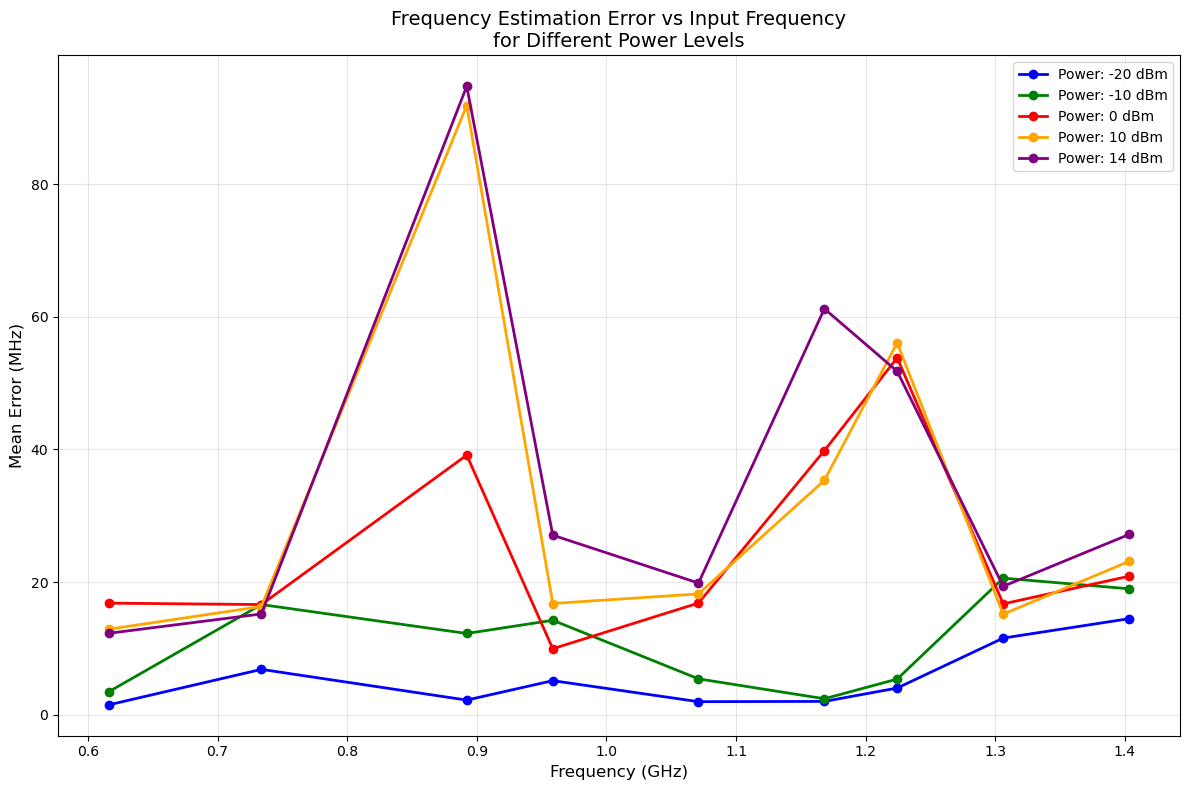

In [26]:
import numpy as np
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import matplotlib.pyplot as plt
import torch as T
import pandas as pd
from scipy import signal
import math
from typing import Tuple, Dict, List
import warnings

# ------------------- Helper Functions ----------------------

def get_data_in_array(dataframe: pd.DataFrame, header_name: str, delim: bool = True, size: int = 400) -> np.ndarray:
    """
    Parse string arrays from CSV into numpy arrays.
    
    Args:
        dataframe: Input DataFrame
        header_name: Column name to extract
        delim: Whether to use comma delimiter (True) or space (False)
        size: Target array size
    
    Returns:
        2D numpy array of shape (len(dataframe), size)
    """
    _results_array = np.zeros([len(dataframe), size])
    
    for i in range(len(dataframe)):
        try:
            _results = dataframe[header_name].iloc[i].strip()[1:-1]
            _results = _results.split(",") if delim else _results.split()
            np_array = [float(value.strip()) for value in _results]
            
            # Ensure we don't exceed the target size
            np_array = np_array[:size]
            _results_array[i, :len(np_array)] = np.array(np_array)
            
        except (ValueError, IndexError) as e:
            print(f"Warning: Error parsing row {i} in column {header_name}: {e}")
            continue
            
    return _results_array

def get_datasets(dataset: pd.DataFrame) -> Tuple[T.utils.data.DataLoader, pd.Series]:
    """
    Create PyTorch DataLoader from dataset.
    
    Args:
        dataset: Input DataFrame containing signal data
        
    Returns:
        Tuple of (DataLoader, all frequencies for each sample)
    """
    x = get_data_in_array(dataframe=dataset, header_name='arcsin_results', delim=True).astype(float)
    y = get_data_in_array(dataframe=dataset, header_name='test_data', delim=True).astype(float)

    # Ensure consistent shape
    x = np.resize(x, (x.shape[0], 400))
    y = np.resize(y, (y.shape[0], 400))

    data_tensor = T.tensor(x, dtype=T.float32)
    targets_tensor = T.tensor(y, dtype=T.float32)

    testing_dataset = T.utils.data.TensorDataset(data_tensor, targets_tensor)
    testing_loader = T.utils.data.DataLoader(testing_dataset, batch_size=1, shuffle=False)
    freqs = dataset['Frequencies'].reset_index(drop=True)  # All frequencies (will repeat)

    return testing_loader, freqs

def get_frequency_component(y: T.Tensor, fs: float = 2e9) -> float:
    """
    Extract dominant frequency from signal using periodogram.
    
    Args:
        y: Input signal tensor
        fs: Sampling frequency
        
    Returns:
        Dominant frequency in MHz
    """
    y_numpy = y.view(-1).cpu().numpy()
    
    # Use next power of 2 for efficient FFT
    N = 2**math.ceil(np.log2(len(y_numpy) * 4))
    
    try:
        f, px = signal.periodogram(y_numpy, window='hann', nfft=N, fs=fs, scaling='spectrum')
        
        # Find frequency with maximum power (excluding DC component)
        peak_idx = np.argmax(px[1:]) + 1  # Skip DC component
        return f[peak_idx] / 1e6  # Return frequency in MHz
        
    except Exception as e:
        print(f"Warning: Error in frequency analysis: {e}")
        return 0.0

def get_errors(loaded_model: T.nn.Module, device: T.device, 
               testing_loader: T.utils.data.DataLoader, freqs: pd.Series) -> Dict[float, float]:
    """
    Calculate prediction errors for each frequency.
    
    Args:
        loaded_model: Trained PyTorch model
        device: Computation device (CPU/GPU)
        testing_loader: DataLoader with test data
        freqs: Series of frequencies corresponding to each sample
        
    Returns:
        Dictionary mapping frequency to mean error
    """
    loaded_model.eval()
    loaded_model.to(device)

    freq_errors = {}  # Store all errors for each frequency
    
    with T.no_grad():
        for i, (data, target) in enumerate(testing_loader):
            data = data.to(device)
            target = target.to(device)

            try:
                output = loaded_model(data)

                f_true = get_frequency_component(target)
                f_pred = get_frequency_component(output)

                current_freq = freqs.iloc[i]
                error = abs(f_true - f_pred)

                # Store error for this frequency
                if current_freq not in freq_errors:
                    freq_errors[current_freq] = []
                freq_errors[current_freq].append(error)
                
            except Exception as e:
                print(f"Warning: Error processing sample {i}: {e}")
                continue

    # Calculate mean error for each frequency
    freq_dict = {freq: np.mean(errors) for freq, errors in freq_errors.items()}
    
    return freq_dict

# ------------------- Main Plotting ------------------------

def plot_freq_vs_error(model_path: str, csv_path: str = 'pvary_fvary_offline_data.csv') -> None:
    """
    Create plots showing error vs frequency for different power levels.
    
    Args:
        model_path: Path to the trained model file
        csv_path: Path to the CSV data file
    """
    try:
        loaded_model = T.jit.load(model_path)
        device = T.device('cuda' if T.cuda.is_available() else 'cpu')
        print(f"Using device: {device}")

        # Load dataset
        dataset = pd.read_csv(
            csv_path,
            skiprows=[0],
            names=['Numbers', 'Frequencies', 'Powers', 'arcsin_results', 'test_data', 'expected_recovered_freq']
        )
        
        print(f"Loaded dataset with {len(dataset)} samples")
        print(f"Available power levels: {sorted(dataset['Powers'].unique())}")
        print(f"Available frequencies: {sorted(dataset['Frequencies'].unique())}")

        powers = [-20, -10, 0, 10, 14]
        color_map = ['blue', 'green', 'red', 'orange', 'purple']

        plt.figure(figsize=(12, 8))

        for i, p in enumerate(powers):
            df_power = dataset[dataset['Powers'] == p].reset_index(drop=True)

            if df_power.empty:
                print(f"No data found for power level {p} dBm")
                continue

            print(f"\nProcessing power level {p} dBm ({len(df_power)} samples)...")
            
            testing_loader, freqs = get_datasets(df_power)
            freq_dict = get_errors(loaded_model, device, testing_loader, freqs)

            if not freq_dict:
                print(f"No valid results for power level {p} dBm")
                continue

            freqs_sorted, errors_sorted = zip(*sorted(freq_dict.items()))
            plt.plot(freqs_sorted, errors_sorted, marker='o', linestyle='-', 
                    color=color_map[i % len(color_map)], label=f'Power: {p} dBm', linewidth=2, markersize=6)

            # Print statistics
            errors_array = np.array(errors_sorted)
            print(f"  Maximum error: {np.max(errors_array):.3f} MHz")
            print(f"  Mean error: {np.mean(errors_array):.3f} MHz")
            print(f"  Minimum error: {np.min(errors_array):.3f} MHz")
            print(f"  Std deviation: {np.std(errors_array):.3f} MHz")

        plt.xlabel("Frequency (GHz)", fontsize=12)
        plt.ylabel("Mean Error (MHz)", fontsize=12)
        plt.title("Frequency Estimation Error vs Input Frequency\nfor Different Power Levels", fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10)
        plt.tight_layout()
        
        # Save with timestamp for uniqueness
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        filename = f"error_vs_frequency_analysis_{timestamp}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved as: {filename}")
        plt.show()

    except FileNotFoundError as e:
        print(f"Error: File not found - {e}")
    except Exception as e:
        print(f"Error: {e}")

# ------------------- Main Execution ------------------------

if __name__ == "__main__":
    # Check if required files exist
    model_file = 'best_model_2807202510.pt'
    csv_file = 'pvary_fvary_offline_data.csv'
    
    if not os.path.exists(model_file):
        print(f"Error: Model file '{model_file}' not found")
    elif not os.path.exists(csv_file):
        print(f"Error: CSV file '{csv_file}' not found")
    else:
        plot_freq_vs_error(model_file, csv_file)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('pvary_fvary_offline_data.csv')
df

,Numbers,Frequencies,Powers,arcsin_results,test_data,expected_recovered_freq
0,1,0.61622,-20,"[0.007578803658831098, -0.26490073853765367, -...","[0.0, 0.018325226773908035, 0.0298692441478974...",0.196750
1,2,0.61622,-20,"[-0.052679244124576224, -0.2392741865149066, -...","[0.0, 0.018325226773908035, 0.0298692441478974...",0.196750
2,3,0.61622,-20,"[-0.10880584143724578, -0.11625223689853345, 0...","[0.0, 0.018325226773908035, 0.0298692441478974...",0.196750
3,4,0.61622,-20,"[-0.09985011133456992, -0.1339286889693414, -0...","[0.0, 0.018325226773908035, 0.0298692441478974...",0.196750
4,5,0.61622,-20,"[-0.11641268059995089, -0.12951205770960758, 0...","[0.0, 0.018325226773908035, 0.0298692441478974...",0.196750
...,...,...,...,...,...,...
48595,296,1.40315,14,"[-0.4084699756357413, -0.443791977536614, -0.0...","[0.0, 1.5637950750882013, 0.5086236166941173, ...",0.448004
48596,297,1.40315,14,"[0.19462578861476978, 0.23079532531229704, -0....","[0.0, 1.5637950750882013, 0.5086236166941173, ...",0.448004
48597,298,1.40315,14,"[0.042492369142273646, 0.03795031326927008, -0...","[0.0, 1.5637950750882013, 0.5086236166941173, ...",0.448004
48598,299,1.40315,14,"[0.07174167623767572, -0.11785865530931347, 0....","[0.0, 1.5637950750882013, 0.5086236166941173, ...",0.448004


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

frequencies = [0.61622, 0.73379, 0.8922 , 0.95858, 1.071  , 1.16814, 1.2243 , 1.30611, 1.40315]
powers = [-20, -10, 0, 10, 14]
df = pd.read_csv('pvary_fvary_offline_data.csv')
    
# Load and filter
sample_df = df[(df['Frequencies'] == 0.62644) & (df['Powers'] == 0)].reset_index(drop=True)

# Convert both arcsin_results and test_data to arrays of floats
sample_df['arcsin_results'] = sample_df['arcsin_results'].apply(
    lambda x: [float(i.strip()) for i in x.strip('[]').split(',')[:400]]
)
sample_df['test_data'] = sample_df['test_data'].apply(
    lambda x: [float(i.strip()) for i in x.strip('[]').split(',')[:400]]
)

# Flatten all samples (multiple rows) into one array each
arcsin_all = np.concatenate(sample_df['arcsin_results'].values)
test_all = np.concatenate(sample_df['test_data'].values)

# Compute absolute error
error = arcsin_all - test_all

# Plot distribution
plt.hist(error, bins=10)
plt.xlabel("Error per sample")
plt.title("Errors for frequency 0.62644 GHz and power 0dBm")
plt.grid(True)
plt.show()


In [ ]:
data = pd.read_csv('pvary_fvary_test_data.csv')
data.shape

In [ ]:
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import matplotlib.pyplot as plt
import torch as T
import pandas as pd
from scipy import signal
import math


def fft_signal(data_, iota):
    '''FFT processing function with error handling'''
    try:
        N = int(2 ** np.ceil(np.log2(len(data_) * 4)))
        f, x = signal.periodogram(data_, window='hann', nfft=N, fs=1e9 * iota, scaling='spectrum')
        f = f / 1e6
        epsilon = 1e-10
        x = 10 * (np.log10((x + epsilon)/ 50e-3))
        return f, x
    except Exception as e:
        print(f"Error in fft_signal: {e}")
        return None, None

def get_data_in_array(dataframe, header_name, delim=True, size=400):
    _results_array = np.zeros([len(dataframe), size])
    for i in range(len(dataframe)):
        _results = dataframe[header_name].iloc[i].strip()[1:-1]
        _results = _results.split(",") if delim else _results.split()
        np_array = [float(value.strip()) for value in _results]
        _results_array[i] = np.array(np_array)[:size]
    return _results_array

def get_datasets(dataset):
    x = get_data_in_array(dataframe=dataset, header_name='arcsin_results', delim=True).astype(float)
    y = get_data_in_array(dataframe=dataset, header_name='test_data', delim=True).astype(float)

    x = np.resize(x, (x.shape[0], 400))
    y = np.resize(y, (y.shape[0], 400))

    data_tensor = T.tensor(x, dtype=T.float32)
    targets_tensor = T.tensor(y, dtype=T.float32)

    testing_dataset = T.utils.data.TensorDataset(data_tensor, targets_tensor)
    testing_loader = T.utils.data.DataLoader(testing_dataset, batch_size=1, shuffle=False)

    return testing_loader

def analyze_model_output(model, data, device):
    """Detailed analysis of model output"""
    data = data.to(device)
    
    with T.no_grad():
        try:
            # Check if model expects different input shape
            if len(data.shape) == 2:  # [batch_size, features]
                model_input = data
            else:  # [batch_size, channels, features] or other
                model_input = data.unsqueeze(0) if data.shape[0] != 1 else data
            
            output = model(model_input)
            
            # Handle different output formats
            if isinstance(output, tuple):
                output = output[0]  # Take first element if tuple
            
            output = output.squeeze().cpu().numpy()
            
            return output
            
        except Exception as e:
            print(f"Error in model forward pass: {e}")
            print(f"Model input shape was: {model_input.shape}")
            return None

def plot_individual_samples(model_path='final_model_2407202509.pt', csv_path='pvary_fvary_offline_data.csv', 
                           max_samples_per_freq=None, max_frequencies=None, save_plots=False):
    """
    Plot each sample individually for each frequency
    
    Args:
        model_path: Path to the PyTorch model
        csv_path: Path to the CSV data file
        max_samples_per_freq: Maximum number of samples to plot per frequency (None for ALL samples)
        max_frequencies: Maximum number of frequencies to process (None for ALL frequencies)
        save_plots: Whether to save plots to files (creates many files if True)
        
    WARNING: Setting both max_samples_per_freq=None and max_frequencies=None will create 
             one individual plot for EVERY sample in your dataset. This could be hundreds 
             or thousands of plots!
    """
    
    # Load model
    try:
        model = T.jit.load(model_path)
        model.eval()
        print("Model loaded successfully")
    except Exception as e:
        print(f"Error loading model: {e}")
        return
    
    device = T.device('cuda' if T.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    try:
        model.to(device)
        print("Model moved to device successfully")
    except Exception as e:
        print(f"Error moving model to device: {e}")

    # Load data
    df = pd.read_csv(csv_path, skiprows=[0], names=[
        'Numbers', 'Frequencies', 'Powers', 'arcsin_results', 'test_data', 'expected_recovered_freq'])
    
    print(f"Data loaded: {len(df)} samples")
    print(f"Unique frequencies: {sorted(df['Frequencies'].unique())}")

    freq_list = sorted(df['Frequencies'].unique())
    
    # Limit frequencies if specified
    if max_frequencies is not None:
        freq_list = freq_list[:max_frequencies]
        print(f"Processing only first {max_frequencies} frequencies")

    for freq_idx, freq in enumerate(freq_list):
        print(f"\n=== Processing frequency {freq_idx+1}/{len(freq_list)}: {freq:.5f} GHz ===")
        
        # Filter dataframe for current frequency
        df_freq = df[df['Frequencies'] == freq].reset_index(drop=True)
        print(f"Found {len(df_freq)} samples for frequency {freq:.5f} GHz")
        
        # Limit samples if specified
        if max_samples_per_freq is not None:
            df_freq = df_freq.head(max_samples_per_freq)
            print(f"Processing only first {max_samples_per_freq} samples")
        else:
            print(f"Processing ALL {len(df_freq)} samples for this frequency")
        
        # Get datasets for the filtered dataframe
        loader = get_datasets(df_freq)
        
        valid_predictions = 0
        zero_predictions = 0
        
        for sample_idx, (data, target) in enumerate(loader):
            print(f"\nProcessing sample {sample_idx+1}/{len(df_freq)} for frequency {freq:.5f} GHz")
            
            # Analyze model output
            output = analyze_model_output(model, data, device)
            target_np = target.squeeze().cpu().numpy()
            input_np = data.squeeze().cpu().numpy()
            
            if output is None:
                print(f"Skipping sample {sample_idx+1} due to model output error")
                continue
            
            # Check if output is meaningful
            is_zero_output = np.allclose(output, 0, atol=1e-10)
            if is_zero_output:
                zero_predictions += 1
                print("WARNING: Model output is all zeros!")
            else:
                valid_predictions += 1
            
            # Create individual plot for this sample
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            fig.suptitle(f'Sample {sample_idx+1} - Frequency: {freq:.5f} GHz', fontsize=16)
            
            # Plot 1: Input signal (arcsin_results)
            axes[0, 0].plot(input_np, label='Input (arcsin_results)', alpha=0.8, linewidth=2, color='blue')
            axes[0, 0].set_title('Input Signal (arcsin_results)')
            axes[0, 0].set_xlabel('Sample')
            axes[0, 0].set_ylabel('Amplitude')
            axes[0, 0].grid(True)
            axes[0, 0].legend()
            
            # Plot 2: Target vs Predicted
            axes[0, 1].plot(target_np, label='Target', color='red', alpha=0.8, linewidth=2)
            
            if not is_zero_output:
                axes[0, 1].plot(output, label='Predicted', color='green', linestyle='--', alpha=0.8, linewidth=2)
            else:
                axes[0, 1].text(0.5, 0.5, 'Prediction is all zeros!', 
                               transform=axes[0, 1].transAxes, ha='center', va='center',
                               bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
            
            axes[0, 1].set_title('Time Domain: Target vs Predicted')
            axes[0, 1].set_xlabel('Sample')
            axes[0, 1].set_ylabel('Amplitude')
            axes[0, 1].grid(True)
            axes[0, 1].legend()
            
            # Plot 3: FFT Comparison
            f_target, x_target = fft_signal(target_np, iota=2)
            
            if f_target is not None:
                axes[1, 0].plot(f_target, x_target, color='red', alpha=0.8, label='Target FFT', linewidth=2)
            
            if not is_zero_output:
                f_pred, x_pred = fft_signal(output, iota=2)
                if f_pred is not None and x_pred is not None:
                    axes[1, 0].plot(f_pred, x_pred, color='green', linestyle='--', alpha=0.8, label='Predicted FFT', linewidth=2)
            else:
                axes[1, 0].text(0.5, 0.5, 'No Prediction FFT\n(output is zeros)', 
                               transform=axes[1, 0].transAxes, ha='center', va='center',
                               bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
            
            axes[1, 0].set_title('FFT Spectrum Comparison')
            axes[1, 0].set_xlabel('Frequency (MHz)')
            axes[1, 0].set_ylabel('Power Spectrum (dB)')
            axes[1, 0].set_xlim(0, 400)  # Changed from 600 to 400
            axes[1, 0].grid(True)
            axes[1, 0].legend()
            
            # Plot 4: Sample Statistics and Info
            stats_text = f"""Sample Information:
Frequency: {freq:.5f} GHz
Sample: {sample_idx+1}/{len(df_freq)}
            
Input Statistics:
  Min: {input_np.min():.6f}
  Max: {input_np.max():.6f}
  Mean: {input_np.mean():.6f}
  Std: {input_np.std():.6f}

Target Statistics:
  Min: {target_np.min():.6f}
  Max: {target_np.max():.6f}
  Mean: {target_np.mean():.6f}
  Std: {target_np.std():.6f}

Prediction Statistics:
  Min: {output.min():.6f}
  Max: {output.max():.6f}
  Mean: {output.mean():.6f}
  Std: {output.std():.6f}
  
Status: {'Valid' if not is_zero_output else 'Zero Output'}"""
            
            axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes, 
                           fontsize=10, verticalalignment='top', fontfamily='monospace')
            axes[1, 1].set_title('Sample Statistics')
            axes[1, 1].axis('off')
            
            plt.tight_layout()
            
            # Create safe filename
            safe_freq = f"{freq:.5f}".replace('.', 'p')
            filename = f"sample_{sample_idx+1:03d}_freq_{safe_freq}GHz.png"
            
            # Save plots if requested
            if save_plots:
                # Create directory if it doesn't exist
                import os
                os.makedirs("./plots", exist_ok=True)
                plt.savefig(f"./plots/{filename}", dpi=300, bbox_inches='tight')
                print(f"Saved: ./plots/{filename}")
            
            plt.show()
            
            print(f"Completed sample {sample_idx+1}/{len(df_freq)}")
        
        print(f"\nFrequency {freq:.5f} GHz Summary:")
        print(f"Total samples processed: {len(df_freq)}")
        print(f"Valid predictions: {valid_predictions}")
        print(f"Zero predictions: {zero_predictions}")

def plot_frequency_summary(model_path='final_model_2807202510.pt', csv_path='pvary_fvary_offline_data.csv'):
    """
    Create a summary plot showing all samples for each frequency in a single plot
    """
    
    # Load model
    try:
        model = T.jit.load(model_path)
        model.eval()
        print("Model loaded successfully")
    except Exception as e:
        print(f"Error loading model: {e}")
        return
    
    device = T.device('cuda' if T.cuda.is_available() else 'cpu')
    model.to(device)

    # Load data
    df = pd.read_csv(csv_path, skiprows=[0], names=[
        'Numbers', 'Frequencies', 'Powers', 'arcsin_results', 'test_data', 'expected_recovered_freq'])
    
    freq_list = sorted(df['Frequencies'].unique())

    for freq_idx, freq in enumerate(freq_list):
        print(f"\nCreating summary plot for frequency {freq:.5f} GHz")
        
        df_freq = df[df['Frequencies'] == freq].reset_index(drop=True)
        loader = get_datasets(df_freq)
        
        # Create summary figure
        fig, axes = plt.subplots(2, 2, figsize=(20, 12))
        fig.suptitle(f'All Samples Summary - Frequency: {freq:.5f} GHz', fontsize=16)
        
        valid_count = 0
        zero_count = 0
        
        colors = plt.cm.tab10(np.linspace(0, 1, min(len(df_freq), 10)))
        
        for sample_idx, (data, target) in enumerate(loader):
            output = analyze_model_output(model, data, device)
            target_np = target.squeeze().cpu().numpy()
            input_np = data.squeeze().cpu().numpy()
            
            if output is None:
                continue
                
            is_zero_output = np.allclose(output, 0, atol=1e-10)
            color = colors[sample_idx % len(colors)]
            alpha = 0.6 if len(df_freq) > 5 else 0.8
            
            if is_zero_output:
                zero_count += 1
            else:
                valid_count += 1
            
            # Plot input signals
            axes[0, 0].plot(input_np, alpha=alpha, color=color, linewidth=1, 
                           label=f'Sample {sample_idx+1}' if sample_idx < 5 else "")
            
            # Plot targets and predictions
            axes[0, 1].plot(target_np, alpha=alpha, color=color, linewidth=1, linestyle='-')
            if not is_zero_output:
                axes[0, 1].plot(output, alpha=alpha, color=color, linewidth=1, linestyle='--')
            
            # Plot FFTs
            f_target, x_target = fft_signal(target_np, iota=2)
            if f_target is not None:
                axes[1, 0].plot(f_target, x_target, alpha=alpha, color=color, linewidth=1, linestyle='-')
                
                if not is_zero_output:
                    f_pred, x_pred = fft_signal(output, iota=2)
                    if f_pred is not None:
                        axes[1, 0].plot(f_pred, x_pred, alpha=alpha, color=color, linewidth=1, linestyle='--')
        
        # Configure summary plots
        axes[0, 0].set_title(f'All Input Signals ({len(df_freq)} samples)')
        axes[0, 0].set_xlabel('Sample')
        axes[0, 0].set_ylabel('Amplitude')
        axes[0, 0].grid(True)
        if len(df_freq) <= 5:
            axes[0, 0].legend()
        
        axes[0, 1].set_title('All Targets (solid) vs Predictions (dashed)')
        axes[0, 1].set_xlabel('Sample')
        axes[0, 1].set_ylabel('Amplitude')
        axes[0, 1].grid(True)
        
        axes[1, 0].set_title('All FFT Spectra - Target (solid) vs Predicted (dashed)')
        axes[1, 0].set_xlabel('Frequency (MHz)')
        axes[1, 0].set_ylabel('Power Spectrum (dB)')
        axes[1, 0].set_xlim(0, 400)  # Changed from 600 to 400
        axes[1, 0].grid(True)
        
        # Summary statistics
        summary_text = f"""Frequency: {freq:.5f} GHz
Total Samples: {len(df_freq)}
Valid Predictions: {valid_count}
Zero Predictions: {zero_count}
Success Rate: {valid_count/len(df_freq)*100:.1f}%"""
        
        axes[1, 1].text(0.1, 0.5, summary_text, transform=axes[1, 1].transAxes, 
                       fontsize=14, verticalalignment='center', fontfamily='monospace')
        axes[1, 1].set_title('Summary Statistics')
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        
        # Save summary plot
        safe_freq = f"{freq:.5f}".replace('.', 'p')
        # plt.savefig(f"./plots/summary_freq_{safe_freq}GHz.png", dpi=300, bbox_inches='tight')
        
        plt.show()

# Example usage:
if __name__ == "__main__":
    
    # OPTION 1: Plot ALL samples individually (creates many plots!)
    # WARNING: This will create one plot for each sample in your dataset
    # If you have 1000 samples across all frequencies, you'll get 1000 individual plots
    print("Creating individual plots for ALL samples...")
    plot_individual_samples()  # No limits = all samples
    
    # OPTION 2: Plot all samples but limit frequencies (recommended for testing first)
    # print("Creating individual plots for all samples in first 2 frequencies...")
    # plot_individual_samples(max_frequencies=2)
    
    # OPTION 3: Create summary plots showing all samples overlaid per frequency
    # This shows all samples but in a more manageable way
    # print("\nCreating frequency summary plots for all samples...")
    # plot_frequency_summary()
    
    # OPTION 4: Hybrid approach - individual plots with reasonable limits
    # print("Creating individual plots with limits...")
    # plot_individual_samples(max_frequencies=5, max_samples_per_freq=20)